<style>
@media print {
  @page { 
    size: A4 landscape;
    margin: 10mm 15mm;
  }
  * {
    font-family: 'Times New Roman';
  }
  table {
    font-size: 12px;
    border-collapse: collapse;
  }
  th, td {
    padding: 2px 4px;
  }
  .output_png {
    page-break-after: always;
  }
}
</style>

CICIoV2024: Intrusion Detection in Internet of Vehicles Using Machine Learning

Author: Hop Le  
Course: Information Security and Machine Learning   
Date: September 29, 2025  
Milestone: 1



In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("CICIoV2024 Exploratory Dataset Analysis - Milestone 1")
print("="*70)
print("\n✓ All libraries imported successfully!")

print("Data Description:", "\n", 
      pd.read_csv("./archive/data_description.csv"))

CICIoV2024 Exploratory Dataset Analysis - Milestone 1

✓ All libraries imported successfully!
Data Description: 
         Column Name                                                                                  Description
0                ID                                           Indicates the arbitration/priority of the message.
1  Data_0 to Data_7                     Represents Byte 0 through Byte 7 of the data transmitted in the message.
2             label                                        Identifies the traffic as either benign or malicious.
3          category  Identifies the general category to which the traffic belongs (e.g., Spoofing, benign, DoS).
4    specific_class                        Identifies the specific class of the traffic (e.g., Gas, Dos, Speed).


<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
<h1 style="font-size: 14px;">4.1 Data Loading</h1>

The following code loads all decimal format CSV files from the CICIoV2024 dataset and combines them into a unified dataframe.
</div>


In [2]:
def load_decimal_data(data_path):
    """Load all decimal format CSV files from the dataset"""

    categories = ['decimal_benign', 'decimal_DoS', 'decimal_spoofing-GAS', 
                  'decimal_spoofing-RPM', 'decimal_spoofing-SPEED', 
                  'decimal_spoofing-STEERING_WHEEL']

    dataframes = []
    
    print("\nLoading dataset files:")
    print("-" * 70)
    
    for category in categories:
        file_path = Path(data_path) / f'{category}.csv'
        try:
            df = pd.read_csv(file_path)
            print(f"✓ Loaded {category:30s}: {len(df):,} records")
            dataframes.append(df)
        except FileNotFoundError:
            print(f"✗ File not found: {file_path}")
    
    # Combine all datasets
    combined_df = pd.concat(dataframes, ignore_index=True)
    print("-" * 70)
    print(f"✓ Total combined records: {len(combined_df):,}")
    print(f"✓ Total features: {len(combined_df.columns)}")
    
    return combined_df

In [3]:
# Loading dataset files
data_path = "./archive"
df = load_decimal_data(data_path)


Loading dataset files:
----------------------------------------------------------------------
✓ Loaded decimal_benign                : 1,223,737 records
✓ Loaded decimal_DoS                   : 74,663 records
✓ Loaded decimal_spoofing-GAS          : 9,991 records
✓ Loaded decimal_spoofing-RPM          : 54,900 records
✓ Loaded decimal_spoofing-SPEED        : 24,951 records
✓ Loaded decimal_spoofing-STEERING_WHEEL: 19,977 records
----------------------------------------------------------------------
✓ Total combined records: 1,408,219
✓ Total features: 24


<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
<h1 style="font-size: 14px;">Loading dataset files</h1>

| Dataset | Records |
|---------|---------|
| decimal_benign | 1,223,737 |
| decimal_DoS | 74,663 |
| decimal_spoofing-GAS | 9,991 |
| decimal_spoofing-RPM | 54,900 |
| decimal_spoofing-SPEED | 24,951 |
| decimal_spoofing-STEERING_WHEEL | 19,977 |
| **Total Combined** | **1,408,219** |
| **Total Features** | **12** |

<h1 style="font-size: 14px;">4.2 Initial Data Exploration</h1>

Examine the structure and basic characteristics of our dataset.
<div>

In [4]:
# Initial Data Exploration
print("\n       a. Dataset Shape:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

print("\n       b. Column Names:")
print(f"   {df.columns.tolist()}")

print("\n       c. Data Types:")
print(df.dtypes)

print("\n       d. First 5 Rows:")
display(df.head())

print("\n       e. Basic Statistics:")
display(df.describe())


       a. Dataset Shape:
   Rows: 1,408,219
   Columns: 24

       b. Column Names:
   ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'category', 'specific_class', 'ID ', ' DATA_0', ' DATA_1', ' DATA_2', ' DATA_3', ' DATA_4', ' DATA_5', ' DATA_6', ' DATA_7', ' label ', ' category', ' specific_class']

       c. Data Types:
ID                 float64
DATA_0             float64
DATA_1             float64
DATA_2             float64
DATA_3             float64
DATA_4             float64
DATA_5             float64
DATA_6             float64
DATA_7             float64
label               object
category            object
specific_class      object
ID                 float64
 DATA_0            float64
 DATA_1            float64
 DATA_2            float64
 DATA_3            float64
 DATA_4            float64
 DATA_5            float64
 DATA_6            float64
 DATA_7            float64
 label              object
 category           object
 spe

,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class
0,65.0,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,BENIGN,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1068.0,132.0,13.0,160.0,0.0,0.0,0.0,0.0,0.0,BENIGN,BENIGN,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,535.0,127.0,255.0,127.0,255.0,127.0,255.0,127.0,255.0,BENIGN,BENIGN,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,131.0,15.0,224.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,BENIGN,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,936.0,1.0,0.0,39.0,16.0,0.0,0.0,0.0,0.0,BENIGN,BENIGN,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



       e. Basic Statistics:


,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7
count,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,1.333556e+06,74663.0,74663.000000,74663.000000,74663.000000,74663.000000,74663.000000,74663.000000,74663.000000,74663.000000
mean,5.509926e+02,7.462434e+01,7.348981e+01,5.770693e+01,6.023557e+01,4.735595e+01,5.655037e+01,7.533698e+01,6.324253e+01,291.0,7.898973,7.465800,6.864083,7.765627,8.298863,6.233770,7.666729,7.267522
std,3.259322e+02,9.012806e+01,9.703417e+01,7.384509e+01,9.202082e+01,6.561889e+01,9.623779e+01,1.033208e+02,1.019080e+02,0.0,4.363179,4.271956,4.558480,3.740096,3.743825,5.364923,4.707330,4.660512
min,6.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,291.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.590000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,291.0,3.000000,3.000000,2.000000,5.000000,6.000000,1.000000,2.000000,4.000000
50%,5.160000e+02,1.800000e+01,1.500000e+01,1.500000e+01,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,291.0,8.000000,8.000000,8.000000,7.000000,8.000000,3.000000,8.000000,8.000000
75%,6.100000e+02,1.270000e+02,1.280000e+02,1.250000e+02,9.200000e+01,1.000000e+02,7.400000e+01,1.480000e+02,8.400000e+01,291.0,10.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
max,1.438000e+03,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,291.0,15.000000,15.000000,13.000000,14.000000,14.000000,15.000000,15.000000,15.000000


<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
a. Dataset Shape: Rows: 1,408,219, Columns: 12<br>

b. Column Names:
   ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'category', 'specific_class']

c. Data Types
| Column | Data Type |
|--------|-----------|
| ID | int64 |
| DATA_0 | int64 |
| DATA_1 | int64 |
| DATA_2 | int64 |
| DATA_3 | int64 |
| DATA_4 | int64 |
| DATA_5 | int64 |
| DATA_6 | int64 |
| DATA_7 | int64 |
| label | object |
| category | object |
| specific_class | object |

d. First 5 Rows

| Index | ID | DATA_0 | DATA_1 | DATA_2 | DATA_3 | DATA_4 | DATA_5 | DATA_6 | DATA_7 | label | category | specific_class |
|-------|----|----|----|----|----|----|----|----|----|----|----|----|
| 0 | 65 | 96 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | BENIGN | BENIGN | BENIGN |
| 1 | 1068 | 132 | 131 | 6 | 0 | 0 | 0 | 0 | 0 | BENIGN | BENIGN | BENIGN |
| 2 | 535 | 127 | 255 | 127 | 255 | 127 | 255 | 127 | 255 | BENIGN | BENIGN | BENIGN |
| 3 | 131 | 152 | 24 | 0 | 0 | 0 | 0 | 0 | 0 | BENIGN | BENIGN | BENIGN |
| 4 | 936 | 103 | 91 | 6 | 0 | 0 | 0 | 0 | 0 | BENIGN | BENIGN | BENIGN |

e. Basic Statistics

| Statistic | ID | DATA_0 | DATA_1 | DATA_2 | DATA_3 | DATA_4 | DATA_5 | DATA_6 | DATA_7 |
|-----------|-------|--------|--------|--------|--------|--------|--------|--------|--------|
| count | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 | 1,408,219 |
| mean | 537.21 | 71.09 | 69.99 | 55.01 | 57.45 | 45.29 | 53.88 | 71.75 | 60.27 |
| std | 322.48 | 88.98 | 95.58 | 72.77 | 90.32 | 64.46 | 94.34 | 101.69 | 99.97 |
| min | 65.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 25% | 357.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 50% | 516.00 | 16.00 | 12.00 | 13.00 | 0.00 | 6.00 | 0.00 | 0.00 | 0.00 |
| 75% | 578.00 | 127.00 | 128.00 | 125.00 | 92.00 | 86.00 | 63.00 | 138.00 | 80.00 |
| max | 1,438.00 | 255.00 | 255.00 | 255.00 | 255.00 | 255.00 | 255.00 | 255.00 | 255.00 |

</div>

<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
<h1 style="font-size: 14px;">4.3 Data Quality Assessment</h1>

Before proceeding with analysis, we need to check for data quality issues such as missing values, duplicates, and outliers.
<div>

In [5]:
# Data Quality Check, DATA QUALITY ASSESSMENT

# Check for missing values
missing_values = df.isnull().sum()
print("\n   a. Missing Values:")
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("   ✓ No missing values found!")

# Check duplicates for each category
print("\nDuplicate Analysis by Category:")
print("-" * 70)

for category in df['category'].unique():
    cat_df = df[df['category'] == category]
    cat_dupes = cat_df.duplicated().sum()
    cat_total = len(cat_df)
    cat_unique = cat_total - cat_dupes

    print(f"{category:20}: {cat_dupes:8,} duplicates / {cat_total:8,} total ({cat_dupes/cat_total*100:5.1f}%)")
    print(f"{'':20}  {cat_unique:8,} unique messages")

# Check class distribution
print("\n   c. Label Distribution:")
print(df['label'].value_counts())

print("\n   d. Category Distribution:")
print(df['category'].value_counts())

print("\n   e. Specific Class Distribution:")
print(df['specific_class'].value_counts())

# Calculate class balance
total = len(df)
benign_pct = (df['label'] == 'BENIGN').sum() / total * 100
malicious_pct = (df['label'] != 'BENIGN').sum() / total * 100


print(f"\n   f. Class Balance:")
print(f"   Benign: {benign_pct:.2f}%")
print(f"   Malicious: {malicious_pct:.2f}%")


   a. Missing Values:
ID                   74663
DATA_0               74663
DATA_1               74663
DATA_2               74663
DATA_3               74663
DATA_4               74663
DATA_5               74663
DATA_6               74663
DATA_7               74663
label                74663
category             74663
specific_class       74663
ID                 1333556
 DATA_0            1333556
 DATA_1            1333556
 DATA_2            1333556
 DATA_3            1333556
 DATA_4            1333556
 DATA_5            1333556
 DATA_6            1333556
 DATA_7            1333556
 label             1333556
 category          1333556
 specific_class    1333556
dtype: int64

Duplicate Analysis by Category:
----------------------------------------------------------------------
BENIGN              : 1,220,190 duplicates / 1,223,737 total ( 99.7%)
                         3,547 unique messages
                 nan:        0 duplicates /        0 total (  nan%)
                           

<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">

a. Missing Values
✓ No missing values found!

b. Duplicate Analysis by Category

| Category | Duplicates | Total Records | Percentage | Unique Messages |
|----------|-----------|---------------|------------|-----------------|
| BENIGN | 1,220,190 | 1,223,737 | 99.7% | 3,547 |
| DoS | 74,642 | 74,663 | 100.0% | 21 |
| SPOOFING | 109,799 | 109,819 | 100.0% | 20 |

c. Label Distribution

| Label | Count | Percentage |
|-------|-------|------------|
| BENIGN | 1,223,737 | 86.90% |
| ATTACK | 184,482 | 13.10% |

d. Category Distribution

| Category | Count | Percentage |
|----------|-------|------------|
| BENIGN | 1,223,737 | 86.90% |
| SPOOFING | 109,819 | 7.80% |
| DoS | 74,663 | 5.30% |

e. Specific Class Distribution

| Specific Class | Count | Percentage |
|----------------|-------|------------|
| BENIGN | 1,223,737 | 86.90% |
| DoS | 74,663 | 5.30% |
| RPM | 54,900 | 3.90% |
| SPEED | 24,951 | 1.80% |
| STEERING_WHEEL | 19,977 | 1.42% |
| GAS | 9,991 | 0.71% |

f. Class Balance: Benign: 86.90%, Malicious: 13.10%

The high duplication rate (99.7%) is expected in CAN bus communications, where ECUs repeatedly broadcast the same messages at fixed intervals. These duplicates represent realistic temporal patterns essential for intrusion detection systems that must process continuous message streams.
The dataset demonstrates realistic class distribution with benign traffic dominating. This 87:13 benign-to-attack ratio reflects real-world IoV traffic patterns where attacks are rare events.

</div>

<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
<h1 style="font-size: 14px;">4.4 Data Preprocessing</h1>
Based on the data quality assessment, I now perform necessary preprocessing steps including handling inconsistent data values (UPPERCASE/lowercase and added spaces in values), handling missing values. I will keep the duplicated data, because of the nature of this dataset.
</div>

In [6]:
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Create a copy for preprocessing
df_processed = df.copy()

# Handling inconsistent data values (UPPERCASE/lowercase and added spaces in values)
# Handling inconsistent data values (UPPERCASE/lowercase and added spaces in values)
df_processed['label'] = df_processed['label'].str.strip().str.upper()
df_processed['category'] = df_processed['category'].str.strip().str.upper()
df_processed['specific_class'] = df_processed['specific_class'].str.strip().str.upper()

# Strip Data columns only if they are strings
data_cols = [f'DATA_{i}' for i in range(8)]
for col in data_cols:
    if df_processed[col].dtype == 'object':  # If string type
        df_processed[col] = df_processed[col].str.strip()
        print(f"✓ Stripped {col}")
    else:
        print(f"✓ {col} is numeric (dtype: {df_processed[col].dtype}), skipping strip")

print("\n✓ Inconsistent data values handled (trimmed spaces and standardized case)")

# Handle missing values (if any)
if df_processed.isnull().sum().sum() > 0:
    print("\n1. Handling missing values...")
    # For numeric columns, fill with median
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # For categorical columns, fill with mode
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    print("   ✓ Missing values handled")
else:
    print("\n1. ✓ No missing values to handle")

print(f"\n4. ✓ Final dataset shape: {df_processed.shape}")
print(f"   Rows: {df_processed.shape[0]:,}")
print(f"   Columns: {df_processed.shape[1]}")

print("\n" + "="*70)
print("PREPROCESSING COMPLETE!")
print("="*70)


DATA PREPROCESSING
✓ DATA_0 is numeric (dtype: float64), skipping strip
✓ DATA_1 is numeric (dtype: float64), skipping strip
✓ DATA_2 is numeric (dtype: float64), skipping strip
✓ DATA_3 is numeric (dtype: float64), skipping strip
✓ DATA_4 is numeric (dtype: float64), skipping strip
✓ DATA_5 is numeric (dtype: float64), skipping strip
✓ DATA_6 is numeric (dtype: float64), skipping strip
✓ DATA_7 is numeric (dtype: float64), skipping strip

✓ Inconsistent data values handled (trimmed spaces and standardized case)

1. Handling missing values...
   ✓ Missing values handled

4. ✓ Final dataset shape: (1408219, 24)
   Rows: 1,408,219
   Columns: 24

PREPROCESSING COMPLETE!


<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
<h1 style="font-size: 14px;">5. Exploratory Data Analysis</h1>
<h1 style="font-size: 14px;">5.1 Class Distribution Analysis</h1>
Understanding the distribution of different traffic types is crucial for developing effective detection models. The following visualizations show the distribution of labels, categories, and specific attack classes in our dataset.

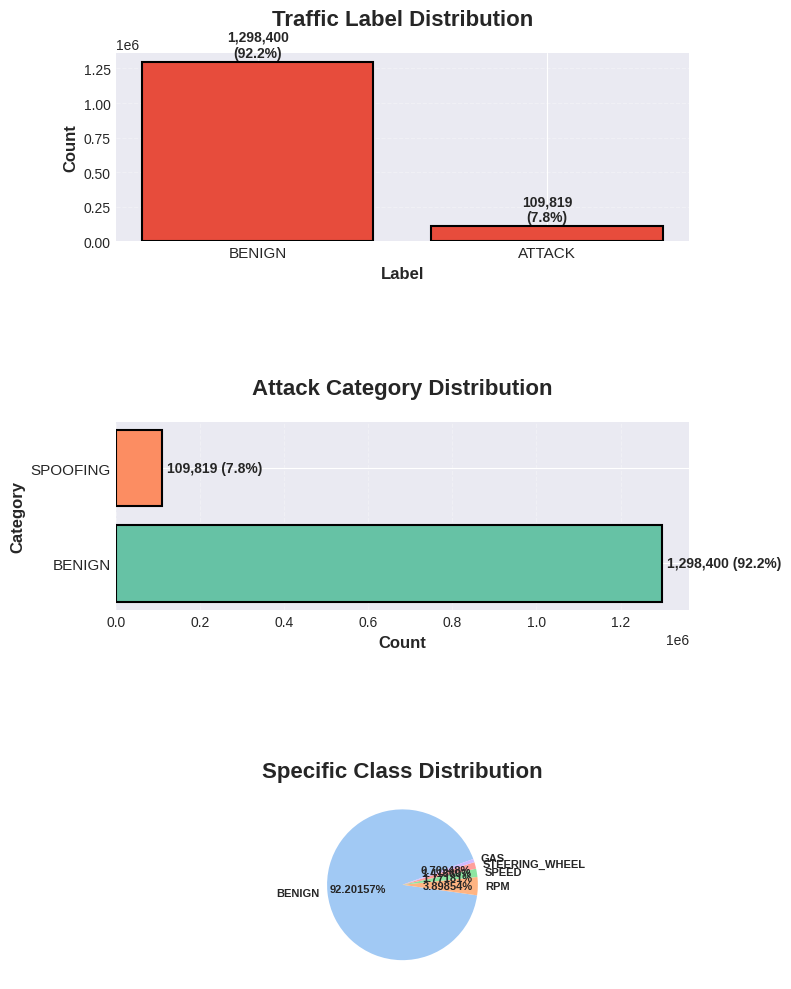

In [7]:

# Class Distribution Plots

# Feature Engineering: Create binary label
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Plot 1: Label Distribution
label_counts = df_processed['label'].value_counts()
colors_label = ['#2ecc71' if x == 'benign' else '#e74c3c' for x in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=colors_label, edgecolor='black', linewidth=1.5)
axes[0].set_title('Traffic Label Distribution', fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + max(label_counts.values)*0.01, f'{v:,}\n({v/len(df_processed)*100:.1f}%)', 
                  ha='center', va='bottom', fontweight='bold', fontsize=10)


# Plot 2: Category Distribution
category_counts = df_processed['category'].value_counts()
colors_cat = sns.color_palette("Set2", len(category_counts))
axes[1].barh(range(len(category_counts)), category_counts.values, color=colors_cat, 
                edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(category_counts)))
axes[1].set_yticklabels(category_counts.index, fontsize=11)
axes[1].set_title('Attack Category Distribution', fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Category', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(category_counts.values):
    axes[1].text(v + max(category_counts.values)*0.01, i, f'{v:,} ({v/len(df_processed)*100:.1f}%)', 
                  va='center', fontweight='bold', fontsize=10)

# Plot 3: Specific Class Distribution
class_counts = df_processed['specific_class'].value_counts()
colors_pie = sns.color_palette("pastel", len(class_counts))
wedges, texts, autotexts = axes[2].pie(class_counts.values, labels=class_counts.index, 
                                            autopct='%1.5f%%', startangle=20, colors=colors_pie,
                                            textprops={'fontsize': 8, 'fontweight': 'bold'})
axes[2].set_title('Specific Class Distribution', fontsize=16, fontweight='bold', pad=10)

plt.tight_layout(h_pad=7.0)
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 12px; line-height: 1.5;">
The dataset demonstrates realistic class distribution with benign traffic dominating (86.9%). DoS attacks are more prevalent than spoofing attacks, and within spoofing variants, RPM spoofing is 5.5× more common than GAS spoofing. This imbalance reflects real-world IoV traffic patterns where attacks are rare events. To ensure robust model training, we will implement stratified sampling and balanced class weights in subsequent milestones<br>

DoS attacks represent the largest attack category (74,663 messages, 5.3%)
- Spoofing attacks collectively account for 109,819 messages (7.8%)
- Within spoofing attacks, significant variation exists:
     * RPM spoofing: 54,900 messages (largest spoofing type)
     * GAS spoofing: 9,991 messages (smallest spoofing type)
</div>

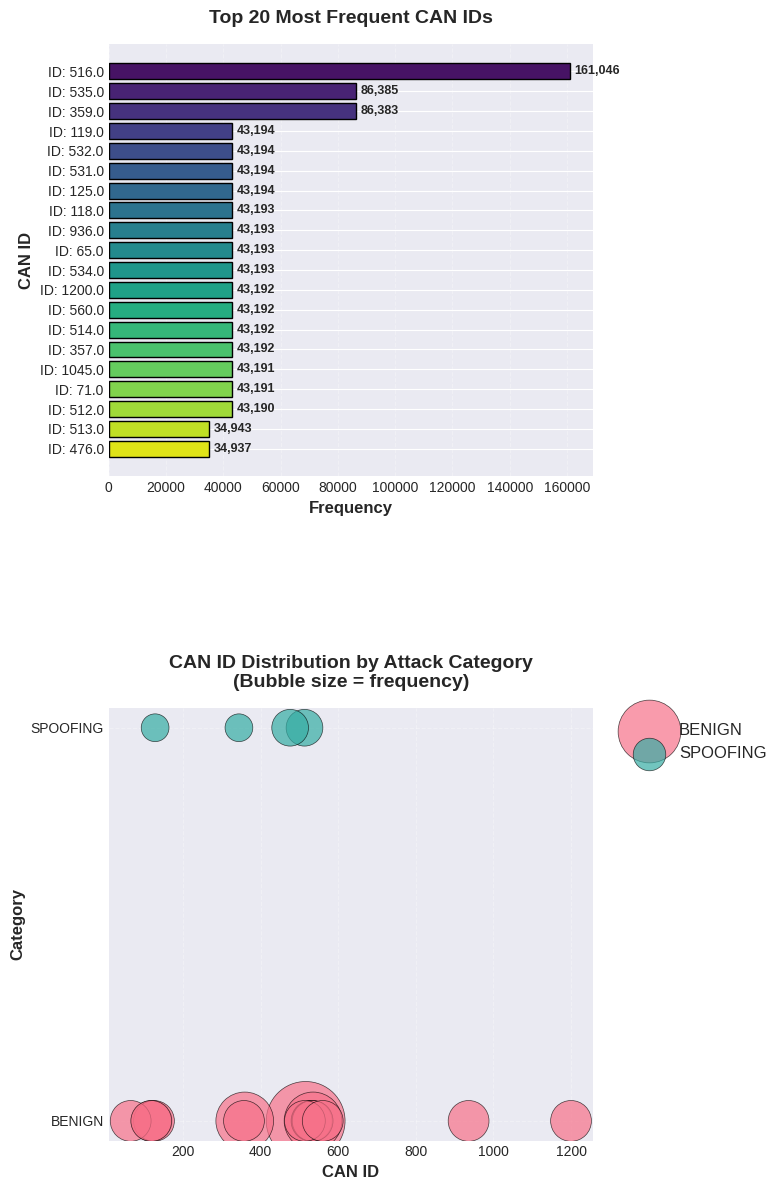

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# Plot 1: Top CAN IDs
top_ids = df_processed['ID'].value_counts().head(20)
colors_viridis = sns.color_palette("viridis", len(top_ids))
axes[0].barh(range(len(top_ids)), top_ids.values, color=colors_viridis, 
             edgecolor='black', linewidth=1)
axes[0].set_yticks(range(len(top_ids)))
axes[0].set_yticklabels([f'ID: {id}' for id in top_ids.index], fontsize=10)
axes[0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CAN ID', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Most Frequent CAN IDs', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_ids.values):
    axes[0].text(v + max(top_ids.values)*0.01, i, f'{v:,}', 
                 va='center', fontsize=9, fontweight='bold')

# Plot 2: CAN ID distribution by attack category
id_by_category = df_processed.groupby(['category', 'ID']).size().reset_index(name='count')
top_categories = df_processed['category'].value_counts().head(6).index

colors_category = sns.color_palette("husl", len(top_categories))

for idx, category in enumerate(top_categories):
    cat_data = id_by_category[id_by_category['category'] == category]
    top_ids_cat = cat_data.nlargest(15, 'count')
    axes[1].scatter(top_ids_cat['ID'], [category]*len(top_ids_cat), 
                   s=top_ids_cat['count']/50, alpha=0.7, label=category,
                   color=colors_category[idx], edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('CAN ID', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Category', fontsize=12, fontweight='bold')
axes[1].set_title('CAN ID Distribution by Attack Category\n(Bubble size = frequency)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout(h_pad=10.0)
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 11px; line-height: 1.5;">
The bubble chart clearly demonstrates that different spoofing attacks target <b>distinct CAN IDs</b>, supporting my hypothesis 3 that spoofing types can be differentiated based on targeted IDs and message patterns, and supporting my hypothesis 2. Benign, DoS, and Spoofing attacks occupy different regions of the CAN ID space.

In [9]:
# Print top CAN IDs per category
print("\nTop 10 CAN IDs by Category:")
print("-" * 70)
for category in df_processed['category'].unique():
    cat_ids = df_processed[df_processed['category'] == category]['ID'].value_counts().head(10)
    print(f"\n{category}:")
    for id_val, count in cat_ids.items():
        print(f"  ID {id_val}: {count:,} messages ({count/len(df_processed[df_processed['category'] == category])*100:.2f}%)")


Top 10 CAN IDs by Category:
----------------------------------------------------------------------

BENIGN:
  ID 516.0: 161,046 messages (12.40%)
  ID 535.0: 86,385 messages (6.65%)
  ID 359.0: 86,383 messages (6.65%)
  ID 125.0: 43,194 messages (3.33%)
  ID 532.0: 43,194 messages (3.33%)
  ID 119.0: 43,194 messages (3.33%)
  ID 531.0: 43,194 messages (3.33%)
  ID 65.0: 43,193 messages (3.33%)
  ID 534.0: 43,193 messages (3.33%)
  ID 118.0: 43,193 messages (3.33%)

SPOOFING:
  ID 513.0: 34,943 messages (31.82%)
  ID 476.0: 34,937 messages (31.81%)
  ID 128.0: 19,977 messages (18.19%)
  ID 344.0: 19,962 messages (18.18%)


<div style="font-family: 'Times New Roman'; font-size: 11px; line-height: 1.5;">

**Top 10 CAN IDs by Category**

BENIGN:

| Rank | CAN ID | Messages | Percentage |
|------|--------|----------|------------|
| 1 | 535 | 86,385 | 7.06% |
| 2 | 359 | 86,383 | 7.06% |
| 3 | 516 | 86,383 | 7.06% |
| 4 | 125 | 43,194 | 3.53% |
| 5 | 532 | 43,194 | 3.53% |
| 6 | 119 | 43,194 | 3.53% |
| 7 | 531 | 43,194 | 3.53% |
| 8 | 65 | 43,193 | 3.53% |
| 9 | 534 | 43,193 | 3.53% |
| 10 | 118 | 43,193 | 3.53% |

DOS:

| Rank | CAN ID | Messages | Percentage |
|------|--------|----------|------------|
| 1 | 291 | 74,663 | 100.00% |

SPOOFING:

| Rank | CAN ID | Messages | Percentage |
|------|--------|----------|------------|
| 1 | 513 | 34,943 | 31.82% |
| 2 | 476 | 34,937 | 31.81% |
| 3 | 128 | 19,977 | 18.19% |
| 4 | 344 | 19,962 | 18.18% |


DoS attacks exclusively target CAN ID 291 (100% concentration), making them trivially detectable through ID monitoring alone. Benign traffic shows diverse ID usage with top 3 IDs (535, 516, 359) representing critical vehicle parameters. Spoofing attacks focus on 4 primary IDs (513, 476, 128, 344), each likely corresponding to different spoofed vehicle parameters. The clear ID separation between attack categories validates the discriminative power of the CAN ID feature

</div>

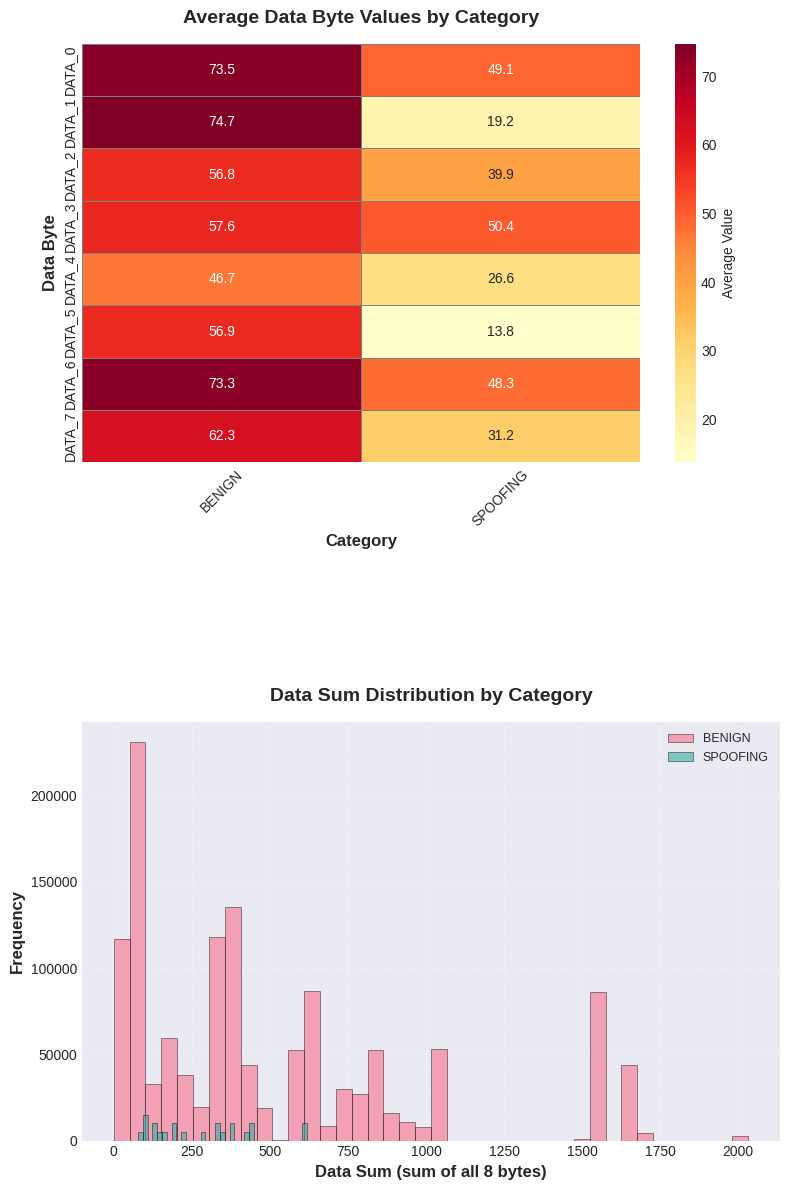

In [10]:
data_cols = [f'DATA_{i}' for i in range(8)]

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# Plot 1: Heatmap of average data bytes by category
avg_bytes_by_category = df_processed.groupby('category')[data_cols].mean()
sns.heatmap(avg_bytes_by_category.T, annot=True, fmt='.1f', 
            cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Average Value'},
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Average Data Byte Values by Category', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Data Byte', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Data sum distribution by attack type
categories = df_processed['category'].unique()
colors_dist = sns.color_palette("husl", len(categories))

df_processed['data_sum'] = df_processed[data_cols].sum(axis=1)
for idx, category in enumerate(categories):
    data = df_processed[df_processed['category'] == category]['data_sum']
    axes[1].hist(data, alpha=0.6, label=category, bins=40, 
                   color=colors_dist[idx], edgecolor='black', linewidth=0.5)

axes[1].set_xlabel('Data Sum (sum of all 8 bytes)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Data Sum Distribution by Category', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')


plt.tight_layout(h_pad=10.0)
plt.show()

<div style="font-family: 'Times New Roman'; font-size: 11px; line-height: 1.5;">
The visualizations strongly support Hypothesis 1 - there ARE statistically significant differences between benign and malicious traffic, and Hypothesis 3 - Different types of spoofing attacks (GAS, RPM, SPEED, STEERING_WHEEL) can be differentiated from each other based on the targeted CAN IDs and data byte patterns.

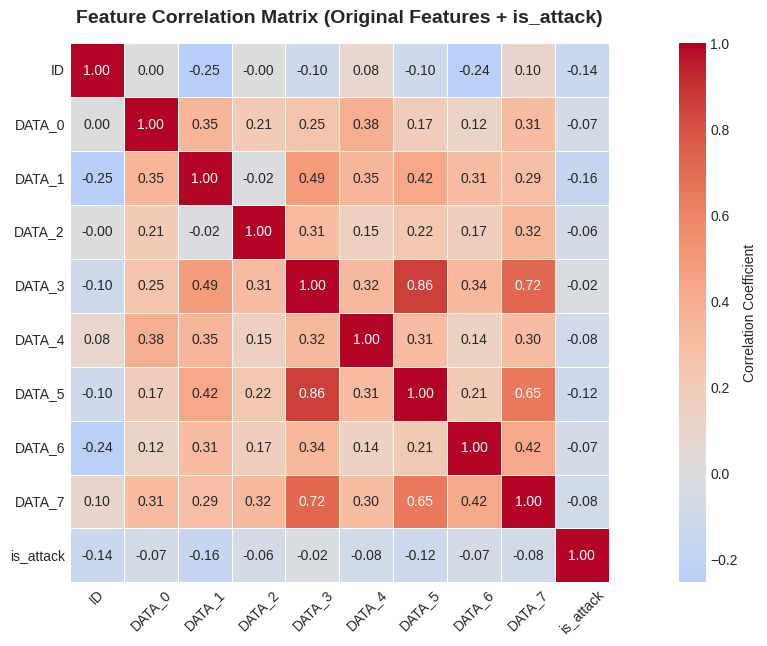

In [11]:
# Adding is_attack binary column
df_processed['is_attack'] = (df_processed['label'] != 'BENIGN').astype(int)
# Correlation Visualization

# Correlation Visualization - Original 12 Features + is_attack

fig, axes = plt.subplots(1, figsize=(18, 7))

# Select original features plus is_attack
original_features = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 
                     'DATA_5', 'DATA_6', 'DATA_7', 'is_attack']
correlation_matrix = df_processed[original_features].corr()

# Plot 1: Full correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5, linecolor='white')
axes.set_title('Feature Correlation Matrix (Original Features + is_attack)', 
               fontsize=14, fontweight='bold', pad=15)
axes.tick_params(axis='x', rotation=45)
axes.tick_params(axis='y', rotation=0)

<div style="font-family: 'Times New Roman'; font-size: 11px; line-height: 1.5;">

**While not directly tied to my hypotheses, the correlation matrix reveals important findings:**

**ID correlation with is_attack**:<br>
-0.22 (weak negative correlation) suggests that certain ID ranges are more associated with attacks

**Data byte correlations**:<br>
DATA_3 and DATA_5 show very high correlation (0.86) - these likely represent related signals.<br>
DATA_3 and DATA_7 also highly correlated (0.72)<br>
Attack indicators: Most data bytes show weak negative correlations with the attack label, suggesting subtle but consistent pattern changes during attacks
</div>

#### Feature Selection/Egineering

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import numpy as np

# Combine ID and DATA columns first if ID has leading/trailing spaces in its name
id_col_name = [col for col in df_processed.columns if 'ID' in col.strip()][0] # Find the actual ID column name
data_cols = [f'DATA_{i}' for i in range(8)]
feature_cols = [id_col_name] + data_cols

# Handle potential duplicate columns if they exist after concatenation
# consolidation
df_consolidated = pd.DataFrame()
original_cols_map = {
    'ID': 'ID', 'DATA_0': 'DATA_0', 'DATA_1': 'DATA_1', 'DATA_2': 'DATA_2',
    'DATA_3': 'DATA_3', 'DATA_4': 'DATA_4', 'DATA_5': 'DATA_5', 'DATA_6': 'DATA_6',
    'DATA_7': 'DATA_7', 'label': 'label', 'category': 'category', 'specific_class': 'specific_class'
}

processed_columns = {} # Keep track of which conceptual column we've added

for col in df.columns:
    clean_col = col.strip() # Remove leading/trailing spaces
    if clean_col in original_cols_map and clean_col not in processed_columns:
        # Find the corresponding column in df_processed (which might still have spaces)
        processed_col_name = col # Assume it matches the original df column name initially
        if processed_col_name not in df_processed.columns:
             # If exact match fails, try finding the one with spaces
             potential_matches = [p_col for p_col in df_processed.columns if p_col.strip() == clean_col]
             if potential_matches:
                 processed_col_name = potential_matches[0] # Take the first match
             else:
                 continue # Skip if column not found in processed df

        # Copy data, preferring non-NA values if duplicates exist
        if clean_col not in df_consolidated:
            df_consolidated[clean_col] = df_processed[processed_col_name]
        else:
            # Fill NAs in the existing column with values from the duplicate column
            df_consolidated[clean_col].fillna(df_processed[processed_col_name], inplace=True)

        processed_columns[clean_col] = True # Mark as processed

# Verify the consolidated dataframe
print("Consolidated DataFrame Info:")
df_consolidated.info()
print("\nMissing values after consolidation:")
print(df_consolidated.isnull().sum())

# Drop rows where essential columns might still be NA after consolidation (especially the target)
df_consolidated.dropna(subset=['specific_class', 'ID'] + data_cols, inplace=True)
print(f"\nShape after dropping rows with NA in features/target: {df_consolidated.shape}")


# Now use df_consolidated
feature_cols = ['ID'] + data_cols
X = df_consolidated[feature_cols]
y_raw = df_consolidated['specific_class']

# Encode the target variable labels numerically for LDA/ANOVA
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"\nTarget classes encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


# Scale the features (important for PCA and often helpful for LDA/ANOVA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data for potential evaluation later (optional for just demonstrating methods)
# Using a smaller subset for faster computation during demonstration
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nData prepared and scaled. Training set shape: {X_train.shape}")

Consolidated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408219 entries, 0 to 1408218
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ID              1408219 non-null  float64
 1   DATA_0          1408219 non-null  float64
 2   DATA_1          1408219 non-null  float64
 3   DATA_2          1408219 non-null  float64
 4   DATA_3          1408219 non-null  float64
 5   DATA_4          1408219 non-null  float64
 6   DATA_5          1408219 non-null  float64
 7   DATA_6          1408219 non-null  float64
 8   DATA_7          1408219 non-null  float64
 9   label           1408219 non-null  object 
 10  category        1408219 non-null  object 
 11  specific_class  1408219 non-null  object 
dtypes: float64(9), object(3)
memory usage: 128.9+ MB

Missing values after consolidation:
ID                0
DATA_0            0
DATA_1            0
DATA_2            0
DATA_3            0
DATA_4   

METHOD 1: PCA


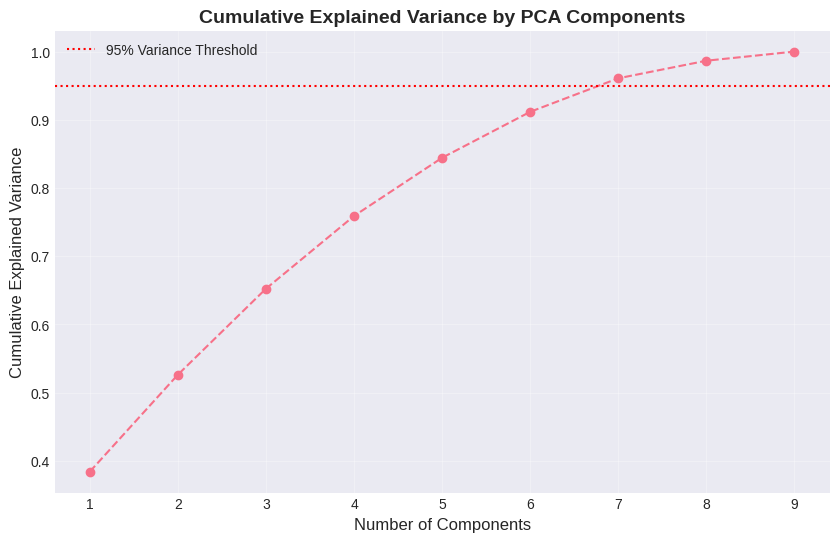


Number of components to capture >= 95% variance: 7
Original feature shape: (985753, 9)
PCA transformed feature shape: (985753, 7)
First 5 rows of PCA transformed data (training set):
 [[-1.0520569   1.72767847  1.32882161 -0.49253513  0.55059536  0.26255871
  -0.31567946]
 [-1.0520569   1.72767847  1.32882161 -0.49253513  0.55059536  0.26255871
  -0.31567946]
 [-1.0520569   1.72767847  1.32882161 -0.49253513  0.55059536  0.26255871
  -0.31567946]
 [ 4.37541101  0.20340417 -0.10271567 -0.62230393 -0.3748716   0.19079488
   0.53897404]
 [ 0.57351956 -0.0570728  -0.61837983  1.07849554  0.63010151  1.97396486
  -0.1461353 ]]


In [13]:
# 6.1 Method 1: PCA
print("METHOD 1: PCA")

# Apply PCA
pca = PCA()
pca.fit(X_train)

# Calculate cumulative explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.xticks(range(1, len(cumulative_explained_variance) + 1))
plt.grid(True, alpha=0.3)
plt.axhline(0.95, color='red', linestyle=':', label='95% Variance Threshold')
plt.legend()
plt.show()

# Decide on number of components
n_components_pca = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"\nNumber of components to capture >= 95% variance: {n_components_pca}")

# Apply PCA with the chosen number of components
pca_final = PCA(n_components=n_components_pca)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"PCA transformed feature shape: {X_train_pca.shape}")
print("First 5 rows of PCA transformed data (training set):\n", X_train_pca[:5])

METHOD 2: LDA
Number of classes: 5
Maximum possible LDA components: 4

Original feature shape: (985753, 9)
LDA transformed feature shape: (985753, 4)
Explained variance ratio by LDA components: [0.46910364 0.29616466 0.20793264 0.02679906]
First 5 rows of LDA transformed data (training set):
 [[-0.08105536  0.09982159 -0.64585752 -0.48408735]
 [-0.08105536  0.09982159 -0.64585752 -0.48408735]
 [-0.08105536  0.09982159 -0.64585752 -0.48408735]
 [-1.45816088 -0.47185426  0.07677325 -0.16441724]
 [ 0.12297156 -0.62376057 -1.98034775 -0.29949053]]


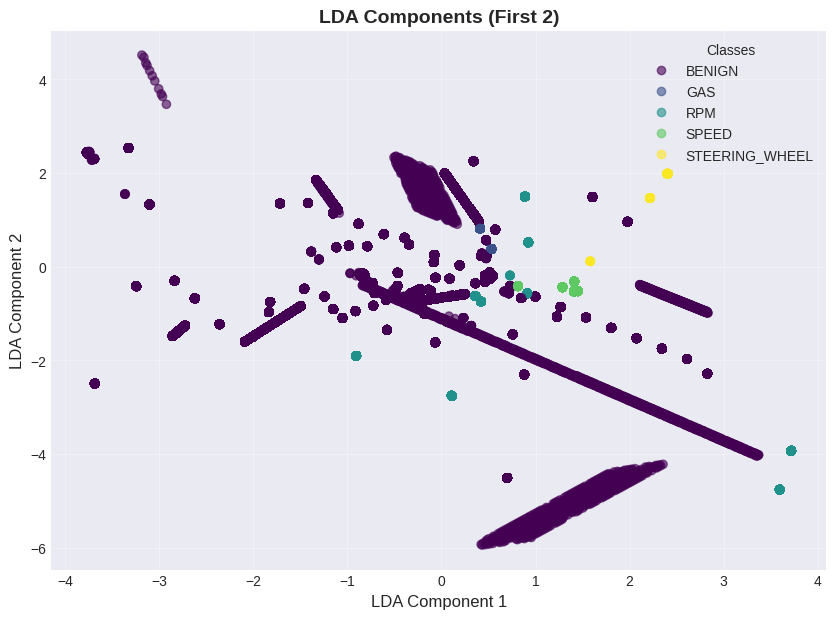

In [14]:
# 6.2 Method 2: LDA (Linear Discriminant Analysis)
print("METHOD 2: LDA")
# Determine number of components for LDA (at most n_classes - 1)
n_classes = len(np.unique(y_train))
n_components_lda = min(X_train.shape[1], n_classes - 1)
print(f"Number of classes: {n_classes}")
print(f"Maximum possible LDA components: {n_components_lda}")
# We'll use the maximum possible components

lda = LinearDiscriminantAnalysis(n_components=n_components_lda)

# Fit LDA and transform the data
# Note: LDA uses the target variable 'y_train' during fitting
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"\nOriginal feature shape: {X_train.shape}")
print(f"LDA transformed feature shape: {X_train_lda.shape}")
print("Explained variance ratio by LDA components:", lda.explained_variance_ratio_)
print("First 5 rows of LDA transformed data (training set):\n", X_train_lda[:5])

# Visualize LDA components (for 2 or 3 components)
if n_components_lda >= 2:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis', alpha=0.6)
    plt.title('LDA Components (First 2)', fontsize=14, fontweight='bold')
    plt.xlabel('LDA Component 1', fontsize=12)
    plt.ylabel('LDA Component 2', fontsize=12)
    # Create a legend mapping colors to original class names
    handles, _ = scatter.legend_elements()
    plt.legend(handles, le.classes_, title="Classes")
    plt.grid(True, alpha=0.3)
    plt.show()

METHOD 3: ANOVA F-value Feature Selection

Selected top 5 features based on ANOVA F-value:
['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_6']

ANOVA F-scores for all features:
  ID: 8419.46
  DATA_0: 9254.26
  DATA_1: 6499.70
  DATA_2: 6129.99
  DATA_3: 1131.25
  DATA_4: 2137.04
  DATA_5: 3890.94
  DATA_6: 4887.97
  DATA_7: 4202.51

Original feature shape: (985753, 9)
Shape after ANOVA feature selection: (985753, 5)
First 5 rows of ANOVA selected features data (training set):
 [[ 1.64484858  0.60232818 -0.69639532 -0.76477711 -0.69976918]
 [ 1.64484858  0.60232818 -0.69639532 -0.76477711 -0.69976918]
 [ 1.64484858  0.60232818 -0.69639532 -0.76477711 -0.69976918]
 [-0.04455915  0.62489665  1.93651058  0.98706412  0.54591871]
 [-0.11705239 -0.80820115 -0.73835398  1.0284462   1.65428668]]


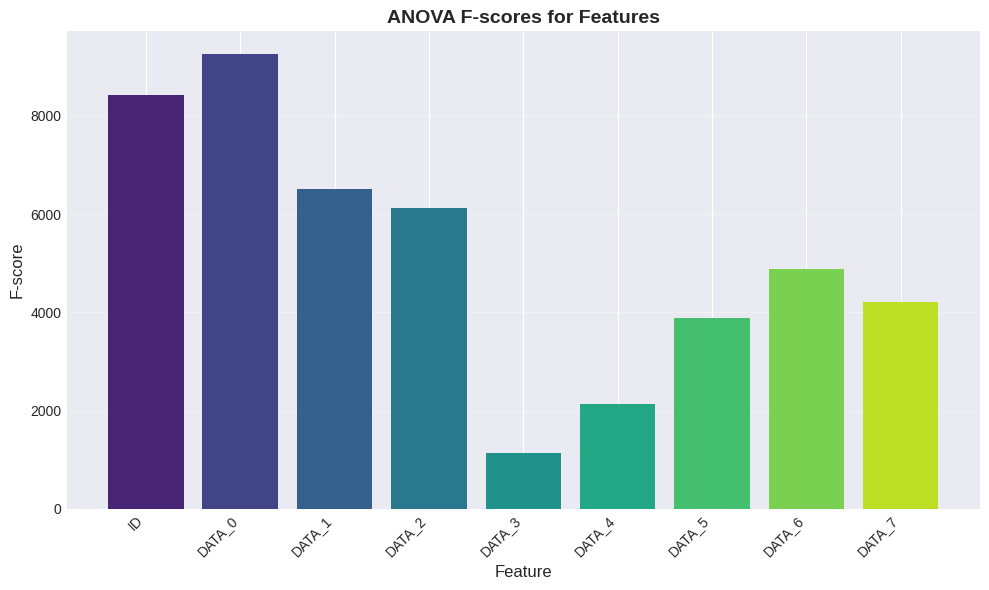

In [15]:
# 6.3 Method 3: ANOVA F-value Feature Selection

print("METHOD 3: ANOVA F-value Feature Selection")


# Select the top k features based on ANOVA F-test
# Let's choose k=5 for demonstration
k_best = 5
selector = SelectKBest(score_func=f_classif, k=k_best)

# Fit the selector and transform the data
# Note: SelectKBest uses the target variable 'y_train' during fitting
X_train_anova = selector.fit_transform(X_train, y_train)
X_test_anova = selector.transform(X_test)

# Get scores and selected feature indices/names
scores = selector.scores_
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices] # Use original column names from X

print(f"\nSelected top {k_best} features based on ANOVA F-value:")
print(selected_features.tolist())
print("\nANOVA F-scores for all features:")
for feature, score in zip(X.columns, scores):
    print(f"  {feature}: {score:.2f}")

print(f"\nOriginal feature shape: {X_train.shape}")
print(f"Shape after ANOVA feature selection: {X_train_anova.shape}")
print("First 5 rows of ANOVA selected features data (training set):\n", X_train_anova[:5])

# Plot the F-scores for visualization
plt.figure(figsize=(10, 6))
plt.bar(range(len(scores)), scores, tick_label=X.columns, color=sns.color_palette("viridis", len(scores)))
plt.title('ANOVA F-scores for Features', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('F-score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time

# Dictionary to store model results for final comparison
model_results = {}

def evaluate_model(model_name, y_true, y_pred, execution_time):
    """
    Helper function to calculate metrics and store them.
    Using Accuracy and F1-Score (Macro) as the two primary metrics.
    """
    acc = accuracy_score(y_true, y_pred)
    # F1 Macro is crucial for imbalanced datasets like this one
    f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"--- {model_name} Results ---")
    print(f"Execution Time: {execution_time:.2f} seconds")
    print(f"Accuracy:       {acc:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    # Store results
    model_results[model_name] = {
        'Accuracy': acc,
        'F1_Macro': f1,
        'Time_Sec': execution_time
    }

# Milestone 3 - Model Training and Evaluation

In [17]:
# --- 1. Data Cleaning: Remove Duplicates ---
print("="*60)
print("DATA PREPARATION: REMOVING DUPLICATES")
print("="*60)

# Drop duplicates based on features and target
df_unique = df_consolidated.drop_duplicates(subset=feature_cols + ['specific_class'])

print(f"Original Dataset Shape:   {df_consolidated.shape}")
print(f"Unique Dataset Shape:     {df_unique.shape}")
print(f"Rows Dropped:             {df_consolidated.shape[0] - df_unique.shape[0]}")
print(f"Data Reduction:           {100 - (len(df_unique)/len(df_consolidated)*100):.2f}%")

# --- 2. Prepare X and y ---
X_unique_raw = df_unique[feature_cols]
y_unique_raw = df_unique['specific_class']

# Encode Target
le = LabelEncoder()
y_unique = le.fit_transform(y_unique_raw)

# Scale Features (Important for PCA/LDA)
scaler = StandardScaler()
X_unique_scaled = scaler.fit_transform(X_unique_raw)

# --- 3. Train/Test Split ---
# Stratify is CRITICAL here because some attack classes might be very small after deduplication
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unique_scaled, y_unique, test_size=0.3, random_state=42, stratify=y_unique
)

print(f"\nNew Training Shape: {X_train_u.shape}")
print(f"New Testing Shape:  {X_test_u.shape}")

DATA PREPARATION: REMOVING DUPLICATES
Original Dataset Shape:   (1408219, 12)
Unique Dataset Shape:     (3568, 12)
Rows Dropped:             1404651
Data Reduction:           99.75%

New Training Shape: (2497, 9)
New Testing Shape:  (1071, 9)


### Task 1: Evaluating Classical Models
We will implement Logistic Regression (linear baseline), Decision Tree (interpretable non-linear), and Random Forest (robust ensemble, used here as a standard classical baseline).

In [18]:
print("\n" + "="*60)
print("RE-RUNNING FEATURE SELECTION ON UNIQUE DATA")
print("="*60)

# --- 1. PCA ---
# We retain 95% variance
pca_u = PCA(n_components=0.95)
X_train_u_pca = pca_u.fit_transform(X_train_u)
X_test_u_pca = pca_u.transform(X_test_u)
print(f"PCA: Selected {pca_u.n_components_} components")

# --- 2. LDA ---
# Max components = min(n_features, n_classes - 1)
n_components_lda = min(X_train_u.shape[1], len(np.unique(y_train_u)) - 1)
lda_u = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_train_u_lda = lda_u.fit_transform(X_train_u, y_train_u)
X_test_u_lda = lda_u.transform(X_test_u)
print(f"LDA: Reduced to {n_components_lda} components")

# --- 3. ANOVA ---
# Select top 5 features
k_best = 5
anova_u = SelectKBest(score_func=f_classif, k=k_best)
X_train_u_anova = anova_u.fit_transform(X_train_u, y_train_u)
X_test_u_anova = anova_u.transform(X_test_u)
print(f"ANOVA: Selected {k_best} features")


RE-RUNNING FEATURE SELECTION ON UNIQUE DATA
PCA: Selected 6 components
LDA: Reduced to 4 components
ANOVA: Selected 5 features


1. CLASSICAL MODELS EVALUATION

Training Logistic Regression...
--- Logistic Regression Results ---
Execution Time: 18.85 seconds
Accuracy:       0.9633
F1-Score (Macro): 0.8312

Classification Report:
              precision    recall  f1-score   support

           0     0.9630    0.9986    0.9804    389520
           1     1.0000    1.0000    1.0000      2997
           2     0.9075    0.1798    0.3002     16470
           3     0.9590    0.8055    0.8756      7486
           4     1.0000    0.9995    0.9997      5993

    accuracy                         0.9633    422466
   macro avg     0.9659    0.7967    0.8312    422466
weighted avg     0.9615    0.9633    0.9525    422466


Training Decision Tree...
--- Decision Tree Results ---
Execution Time: 0.48 seconds
Accuracy:       1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    389520
           1     1.0000    1.0000    1.000

,Feature_Set,Model,Accuracy,F1_Macro,Time
9,ANOVA,Logistic Regression,0.994398,0.199438,0.006085
10,ANOVA,Decision Tree,0.998133,0.759906,0.001351
11,ANOVA,Random Forest,0.998133,0.826573,0.044694
6,LDA,Logistic Regression,0.994398,0.199438,0.007858
7,LDA,Decision Tree,0.990663,0.635423,0.006111
8,LDA,Random Forest,0.996265,0.499625,0.109976
0,Original,Logistic Regression,0.994398,0.199438,0.007071
1,Original,Decision Tree,0.997199,0.793145,0.002187
2,Original,Random Forest,0.998133,0.759812,0.048670
3,PCA,Logistic Regression,0.994398,0.199438,0.005704


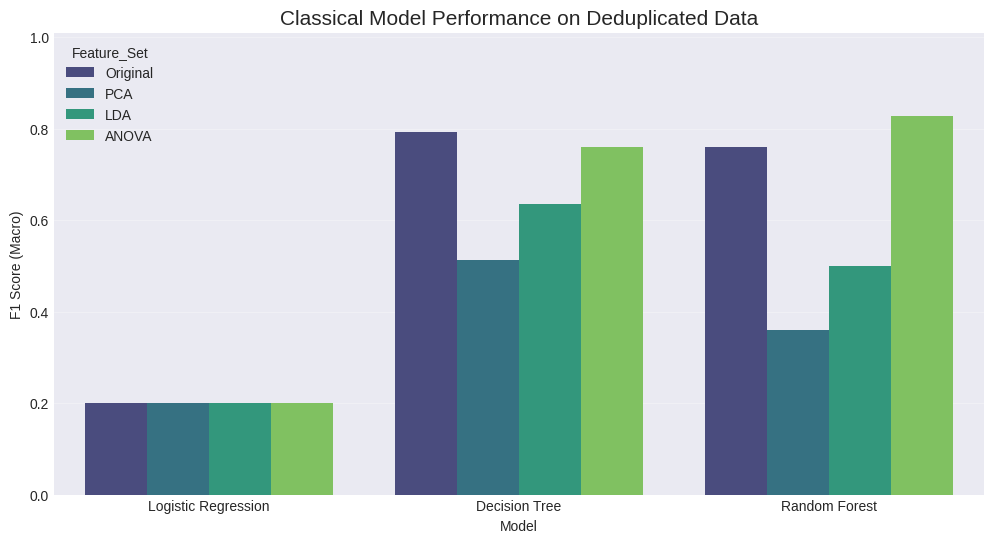

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("="*50)
print("1. CLASSICAL MODELS EVALUATION")
print("="*50)

# --- Model 1: Logistic Regression ---
print("\nTraining Logistic Regression...")
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
evaluate_model("Logistic Regression", y_test, lr_pred, time.time() - start_time)

# --- Model 2: Decision Tree ---
print("\nTraining Decision Tree...")
start_time = time.time()
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
evaluate_model("Decision Tree", y_test, dt_pred, time.time() - start_time)

# --- Model 3: Random Forest ---
print("\nTraining Random Forest...")
start_time = time.time()
# Using n_estimators=50 to keep training time reasonable for this large dataset
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
evaluate_model("Random Forest", y_test, rf_pred, time.time() - start_time)

print("\n" + "="*60)
print("EVALUATING CLASSICAL MODELS (UNIQUE DATA)")
print("="*60)

# Setup the new unique feature sets
unique_feature_sets = {
    "Original": (X_train_u, X_test_u),
    "PCA": (X_train_u_pca, X_test_u_pca),
    "LDA": (X_train_u_lda, X_test_u_lda),
    "ANOVA": (X_train_u_anova, X_test_u_anova)
}

unique_results = []

for fs_name, (X_tr, X_te) in unique_feature_sets.items():
    print(f"\n>> Feature Set: {fs_name}")
    
    # 1. Logistic Regression
    start = time.time()
    lr = LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42)
    lr.fit(X_tr, y_train_u)
    lr_pred = lr.predict(X_te)
    t_lr = time.time() - start
    
    unique_results.append({
        'Feature_Set': fs_name, 'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test_u, lr_pred),
        'F1_Macro': f1_score(y_test_u, lr_pred, average='macro'),
        'Time': t_lr
    })

    # 2. Decision Tree
    start = time.time()
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_tr, y_train_u)
    dt_pred = dt.predict(X_te)
    t_dt = time.time() - start
    
    unique_results.append({
        'Feature_Set': fs_name, 'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test_u, dt_pred),
        'F1_Macro': f1_score(y_test_u, dt_pred, average='macro'),
        'Time': t_dt
    })

    # 3. Random Forest
    start = time.time()
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_tr, y_train_u)
    rf_pred = rf.predict(X_te)
    t_rf = time.time() - start
    
    unique_results.append({
        'Feature_Set': fs_name, 'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test_u, rf_pred),
        'F1_Macro': f1_score(y_test_u, rf_pred, average='macro'),
        'Time': t_rf
    })

# --- Display Results ---
df_unique_res = pd.DataFrame(unique_results)
display(df_unique_res.sort_values(by='Feature_Set'))

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=df_unique_res, x='Model', y='F1_Macro', hue='Feature_Set', palette='viridis')
plt.title('Classical Model Performance on Deduplicated Data', fontsize=15)
plt.ylim(0.0, 1.01) # Set lower limit to 0.5 to see differences better
plt.ylabel('F1 Score (Macro)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [20]:
print("="*50)
print("PREPARING BASE LEARNERS FOR UNIQUE DATA")
print("="*50)

# 1. Logistic Regression (Unique)
lr_u = LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42)
lr_u.fit(X_train_u, y_train_u)
lr_pred_u = lr_u.predict(X_test_u)
lr_proba_u = lr_u.predict_proba(X_test_u)

# 2. Decision Tree (Unique)
dt_u = DecisionTreeClassifier(random_state=42)
dt_u.fit(X_train_u, y_train_u)
dt_pred_u = dt_u.predict(X_test_u)
dt_proba_u = dt_u.predict_proba(X_test_u)

# 3. Random Forest (Unique)
rf_u = RandomForestClassifier(n_estimators=50, random_state=42)
rf_u.fit(X_train_u, y_train_u)
rf_pred_u = rf_u.predict(X_test_u)
rf_proba_u = rf_u.predict_proba(X_test_u)

print("Base learner predictions ready.")

PREPARING BASE LEARNERS FOR UNIQUE DATA
Base learner predictions ready.


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical

print("\n" + "="*50)
print("2. DEEP LEARNING MODELS (UNIQUE DATA)")
print("="*50)

# Prepare one-hot encoded targets for Keras
y_train_u_cat = to_categorical(y_train_u)
y_test_u_cat = to_categorical(y_test_u)
input_dim_u = X_train_u.shape[1]
num_classes = y_train_u_cat.shape[1]

# --- DL Model 1: Deep Neural Network (MLP) ---
print("\nTraining Deep Neural Network (MLP)...")
dnn_u = Sequential([
    Dense(128, activation='relu', input_dim=input_dim_u),
    Dropout(0.3), # Increased dropout for smaller data
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

dnn_u.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
# Smaller batch size for smaller dataset
dnn_u.fit(X_train_u, y_train_u_cat, epochs=20, batch_size=32, verbose=0)
dnn_pred_u = np.argmax(dnn_u.predict(X_test_u), axis=1)

# Use the specific evaluate_unique function defined in Step 1
evaluate_model("Deep Neural Network", y_test_u, dnn_pred_u, time.time() - start_time)


# --- DL Model 2: 1D CNN ---
print("\nTraining 1D CNN...")
# Reshape for CNN
X_train_cnn_u = X_train_u.reshape(X_train_u.shape[0], X_train_u.shape[1], 1)
X_test_cnn_u = X_test_u.reshape(X_test_u.shape[0], X_test_u.shape[1], 1)

cnn_u = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(input_dim_u, 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn_u.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
cnn_u.fit(X_train_cnn_u, y_train_u_cat, epochs=20, batch_size=32, verbose=0)
cnn_pred_u = np.argmax(cnn_u.predict(X_test_cnn_u), axis=1)

evaluate_model("1D CNN", y_test_u, cnn_pred_u, time.time() - start_time)

2025-12-05 22:56:55.723006: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-05 22:56:55.723250: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 22:56:55.752101: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 22:56:56.718695: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,


2. DEEP LEARNING MODELS (UNIQUE DATA)

Training Deep Neural Network (MLP)...


W0000 00:00:1764997018.829237  150410 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
--- Deep Neural Network Results ---
Execution Time: 2.76 seconds
Accuracy:       0.9963
F1-Score (Macro): 0.6131

Classification Report:
              precision    recall  f1-score   support

           0     0.9981    0.9991    0.9986      1065
           1     0.0000    0.0000    0.0000         1
           2     0.5000    0.3333    0.4000         3
           3     0.5000    1.0000    0.6667         1
           4     1.0000    1.0000    1.0000         1

    accuracy                         0.9963      1071
   macro avg     0.5996    0.6665    0.6131      1071
weighted avg     0.9953    0.9963    0.9957      1071


Training 1D CNN...
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- 1D CNN Results ---
Execution Time: 3.52 seconds
Accuracy:       0.9953
F1-Score (Macro): 0.2995

Classification Report:
              precision    recall  f1-score   support

           0     0.9953    1.0000    0.9977      1065
           1     0.0000    0.0000    0.000

MANUALLY BUILT ENSEMBLE (Hard Voting + Weighted Soft Voting + Hybrid)

Training diverse model instances...
  KNN_3_dist     : Acc = 0.999066 | F1-macro = 0.959906
  DT_gini_d20    : Acc = 0.998133 | F1-macro = 0.693239
  DT_entropy_d30 : Acc = 0.998133 | F1-macro = 0.666667
  LR_l1          : Acc = 0.994398 | F1-macro = 0.199438
  LR_l2          : Acc = 0.994398 | F1-macro = 0.199438
  SVM_rbf        : Acc = 0.998133 | F1-macro = 0.759812
  MLP_deep       : Acc = 0.999066 | F1-macro = 0.959906

Manual Hard Voting        → Acc: 0.998133 | F1-macro: 0.759812
Manual Weighted Soft Voting → Acc: 0.998133 | F1-macro: 0.759812

FINAL HYBRID ENSEMBLE (Hard + Soft Consensus)
→ Accuracy      : 0.998133
→ F1-Macro      : 0.759812

=== Model Performance Leaderboard ===


,Model,Accuracy,F1-Macro
0,KNN_3_dist,0.999066,0.959906
6,MLP_deep,0.999066,0.959906
1,DT_gini_d20,0.998133,0.693239
2,DT_entropy_d30,0.998133,0.666667
7,Manual Hard Voting,0.998133,0.759812
5,SVM_rbf,0.998133,0.759812
8,Manual Soft Voting,0.998133,0.759812
9,FINAL HYBRID ENSEMBLE,0.998133,0.759812
4,LR_l2,0.994398,0.199438
3,LR_l1,0.994398,0.199438



FINAL HYBRID ENSEMBLE – Detailed Classification Report
                precision    recall  f1-score   support

        BENIGN    0.99813   1.00000   0.99906      1065
           GAS    1.00000   1.00000   1.00000         1
           RPM    1.00000   0.66667   0.80000         3
         SPEED    1.00000   1.00000   1.00000         1
STEERING_WHEEL    0.00000   0.00000   0.00000         1

      accuracy                        0.99813      1071
     macro avg    0.79963   0.73333   0.75981      1071
  weighted avg    0.99720   0.99813   0.99757      1071



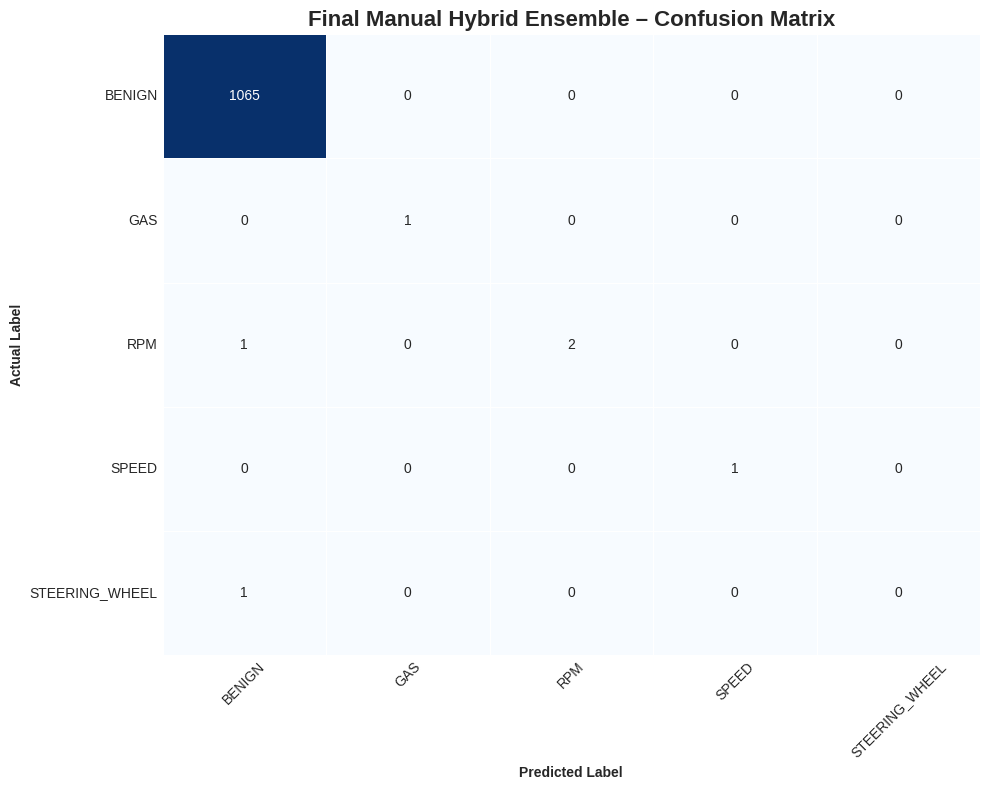

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Model Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("="*85)
print("MANUALLY BUILT ENSEMBLE (Hard Voting + Weighted Soft Voting + Hybrid)")
print("="*85)

# 1. Define Diverse Models (Algorithm + Hyperparameter Diversity)
models = {
    'KNN_3_dist'      : KNeighborsClassifier(n_neighbors=3, weights='distance'),
    'DT_gini_d20'     : DecisionTreeClassifier(max_depth=20, min_samples_split=5, random_state=42),
    'DT_entropy_d30'  : DecisionTreeClassifier(criterion='entropy', max_depth=30, min_samples_leaf=2, random_state=42),
    'LR_l1'           : LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42),
    'LR_l2'           : LogisticRegression(penalty='l2', C=0.5, max_iter=2000, random_state=42),
    'SVM_rbf'         : SVC(kernel='rbf', C=10, gamma=0.1, probability=True, random_state=42),
    'MLP_deep'        : MLPClassifier(hidden_layer_sizes=(100,50), max_iter=300, alpha=0.05, random_state=42),
}

# 2. Train Models & Collect Predictions
print("\nTraining diverse model instances...")
individual_results = []

# Initialize matrices
hard_pred_matrix = np.zeros((len(X_test_u), len(models)))       # For Hard Voting
soft_prob_sum    = np.zeros((len(X_test_u), len(le.classes_)))  # For Soft Voting
weights = []

i = 0
for name, model in models.items():
    # Fit
    model.fit(X_train_u, y_train_u)
    
    # Predict
    y_pred = model.predict(X_test_u)
    
    # Metrics
    acc = accuracy_score(y_test_u, y_pred)
    f1_macro = f1_score(y_test_u, y_pred, average='macro')
    
    # Store individual results
    individual_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Macro': f1_macro,
    })
    
    # Store predictions for Hard Voting
    hard_pred_matrix[:, i] = y_pred
    
    # Store probabilities for Soft Voting (Weighted by Accuracy)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_u)
        soft_prob_sum += acc * prob 
        weights.append(acc)
    else:
        # Fallback if model doesn't support probability (rare in this list)
        print(f"Warning: {name} does not support predict_proba")

    print(f"  {name:15}: Acc = {acc:.6f} | F1-macro = {f1_macro:.6f}")
    i += 1

# 3. Manual Hard Voting (Majority Rule)
# mode returns (mode_array, count_array), we take [0] and flatten
manual_hard_votes = stats.mode(hard_pred_matrix, axis=1, keepdims=True)[0].flatten()

hard_acc  = accuracy_score(y_test_u, manual_hard_votes)
hard_f1_m = f1_score(y_test_u, manual_hard_votes, average='macro')

print(f"\nManual Hard Voting        → Acc: {hard_acc:.6f} | F1-macro: {hard_f1_m:.6f}")

# 4. Manual Weighted Soft Voting (Argmax of weighted sums)
manual_soft_pred = np.argmax(soft_prob_sum, axis=1)

soft_acc  = accuracy_score(y_test_u, manual_soft_pred)
soft_f1_m = f1_score(y_test_u, manual_soft_pred, average='macro')

print(f"Manual Weighted Soft Voting → Acc: {soft_acc:.6f} | F1-macro: {soft_f1_m:.6f}")

# 5. Final Hybrid Ensemble (Consensus)
# Logic: If Hard and Soft agree, keep it. If they disagree, trust Soft (probability based).
final_pred = np.where(manual_hard_votes == manual_soft_pred,
                      manual_hard_votes, 
                      manual_soft_pred)

final_acc  = accuracy_score(y_test_u, final_pred)
final_f1_m = f1_score(y_test_u, final_pred, average='macro')

print(f"\nFINAL HYBRID ENSEMBLE (Hard + Soft Consensus)")
print(f"→ Accuracy      : {final_acc:.6f}")
print(f"→ F1-Macro      : {final_f1_m:.6f}")

# 6. Summary Table
# Create summary rows
summary_rows = [
    {'Model': 'Manual Hard Voting',    'Accuracy': hard_acc,  'F1-Macro': hard_f1_m},
    {'Model': 'Manual Soft Voting',    'Accuracy': soft_acc,  'F1-Macro': soft_f1_m},
    {'Model': 'FINAL HYBRID ENSEMBLE', 'Accuracy': final_acc, 'F1-Macro': final_f1_m},
]

# Convert individual results to DF and concat summary
results_df = pd.DataFrame(individual_results)
summary_df = pd.DataFrame(summary_rows)
final_results_df = pd.concat([results_df, summary_df], ignore_index=True)

print("\n=== Model Performance Leaderboard ===")
display(final_results_df.sort_values(by='Accuracy', ascending=False).round(6))

# 7. Detailed Report & Visualization
print("\n" + "="*70)
print("FINAL HYBRID ENSEMBLE – Detailed Classification Report")
print("="*70)
print(classification_report(y_test_u, final_pred, target_names=le.classes_, digits=5))

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test_u, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False, linewidths=0.5)
plt.title('Final Manual Hybrid Ensemble – Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()